# Phase D2 C+P+X model-mechanism review

This notebook reads sealed prediction and rank-evaluation artifacts only. It
does not fit a model, load a training label, calculate a candidate threshold,
access a network, or write beneath the data root. The evidence is retrospective
hypothesis development and robustness because D2 and D2-NM results motivated
this test.

In [1]:
from pathlib import Path
import hashlib
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PRIMARY = Path("D:/Stock/data/ATS/phase_d_ml/mechanism_runs/phase-d2-no-m-linear-mechanism-20260903-v1")
REPRO = Path("D:/Stock/data/ATS/phase_d_ml/mechanism_runs/phase-d2-no-m-linear-mechanism-20260903-v1-reproduction")
EVALUATION = Path("D:/Stock/data/ATS/phase_d_ml/mechanism_evaluation_runs/phase-d2-no-m-linear-mechanism-evaluation-20260903-v1")
INDEPENDENT = Path("D:/Stock/data/ATS/phase_d_ml/mechanism_reproductions/phase-d2-no-m-linear-mechanism-independent-20260903-v1")

def load(name):
    return json.loads((EVALUATION / name).read_text(encoding="utf-8"))

assert all(path.is_dir() for path in (PRIMARY, REPRO, EVALUATION, INDEPENDENT))
assert hashlib.sha256((PRIMARY / "predictions.parquet").read_bytes()).hexdigest() == hashlib.sha256((REPRO / "predictions.parquet").read_bytes()).hexdigest()
integrity, verdict, contrasts, diagnostics = load("integrity.json"), load("verdict.json"), load("contrasts.json"), load("diagnostics.json")
sessions = pd.read_parquet(EVALUATION / "per_session.parquet")
independent = json.loads((INDEPENDENT / "results.json").read_text(encoding="utf-8"))
assert integrity["independent_evaluation_match"] is True
assert verdict["verdict"] == independent["decision_core"]["scientific_verdict_if_all_integrity_checks_pass"]
print("Sealed prediction, reproduction, and two evaluators: PASS")

Sealed prediction, reproduction, and two evaluators: PASS


## What is being separated

`RICH_NO_M_LINEAR − C_LINEAR` measures whether adding P+X helps under the same
Ridge procedure. `RICH_NO_M_LIGHTGBM − RICH_NO_M_LINEAR` then isolates the
increment associated with nonlinear estimation while holding the 18 C+P+X
features fixed. Every practical claim is also protected against both frozen
conventional comparators.

,mean_session_ic,median_session_ic
C_LINEAR,+0.01420,+0.02412
C_LIGHTGBM,-0.00247,-0.00514
RICH_NO_M_LINEAR,+0.03012,+0.02767
RICH_NO_M_LIGHTGBM,+0.04376,+0.04909


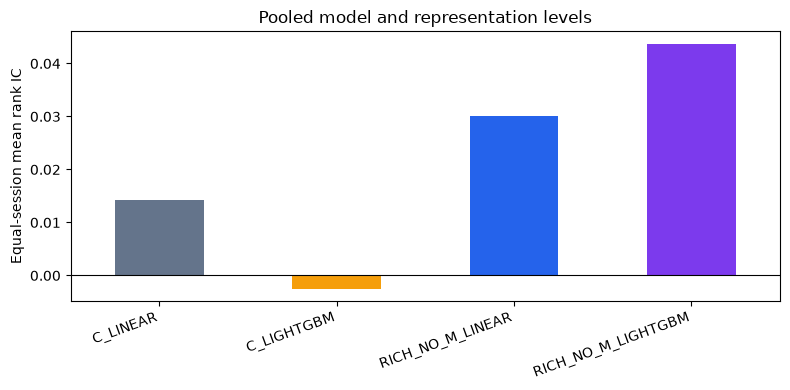

In [2]:
cells = ["C_LINEAR", "C_LIGHTGBM", "RICH_NO_M_LINEAR", "RICH_NO_M_LIGHTGBM"]
cell_table = pd.DataFrame({
    "mean_session_ic": {cell: sessions[f"ic__{cell}"].mean() for cell in cells},
    "median_session_ic": {cell: sessions[f"ic__{cell}"].median() for cell in cells},
})
display(cell_table.style.format("{:+.5f}"))
ax = cell_table["mean_session_ic"].plot(kind="bar", color=["#64748b", "#f59e0b", "#2563eb", "#7c3aed"], figsize=(8, 4))
ax.axhline(0, color="black", linewidth=.8); ax.set_ylabel("Equal-session mean rank IC")
ax.set_title("Pooled model and representation levels"); plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

In [3]:
names = ["RIDGE_VS_C_LINEAR", "RIDGE_VS_C_LIGHTGBM", "NONLINEAR_INCREMENT", "LIGHTGBM_VS_C_LINEAR", "LIGHTGBM_VS_C_LIGHTGBM"]
summary = pd.DataFrame([{
    "contrast": name,
    "mean_delta": contrasts[name]["pooled_mean_delta"],
    "median_delta": contrasts[name]["pooled_median_delta"],
    "positive_half_years": contrasts[name]["positive_half_year_count"],
    "positive_sessions": contrasts[name]["positive_session_fraction"],
    "interval_low": contrasts[name]["moving_block_95_interval"]["lower"],
    "interval_high": contrasts[name]["moving_block_95_interval"]["upper"],
    "broad_increment": contrasts[name]["broad_increment"],
} for name in names]).set_index("contrast")
display(summary.style.format({"mean_delta":"{:+.5f}", "median_delta":"{:+.5f}", "positive_sessions":"{:.1%}", "interval_low":"{:+.5f}", "interval_high":"{:+.5f}"}))

,mean_delta,median_delta,positive_half_years,positive_sessions,interval_low,interval_high,broad_increment
contrast,,,,,,,
RIDGE_VS_C_LINEAR,+0.01592,+0.01361,3,54.1%,-0.02035,+0.05545,FAIL
RIDGE_VS_C_LIGHTGBM,+0.03259,+0.03468,6,58.4%,-0.00653,+0.07042,PASS
NONLINEAR_INCREMENT,+0.01363,+0.01600,5,54.6%,-0.01645,+0.04235,PASS
LIGHTGBM_VS_C_LINEAR,+0.02955,+0.02326,4,54.8%,-0.00874,+0.07065,FAIL
LIGHTGBM_VS_C_LIGHTGBM,+0.04622,+0.04651,6,60.8%,+0.01897,+0.07202,PASS


,Ridge−C_LINEAR,Ridge−C_LIGHTGBM,LightGBM−Ridge
RETRO_2023_H1,+0.15807,+0.06971,+0.03477
RETRO_2023_H2,-0.01239,+0.00156,+0.00209
RETRO_2024_H1,-0.03421,-0.02797,+0.02796
RETRO_2024_H2,-0.04408,+0.00128,+0.06451
RETRO_2025_H1,+0.04686,+0.03214,-0.02385
RETRO_2025_H2,-0.00285,+0.04378,+0.04832
RETRO_2026_H1,+0.00142,+0.10879,-0.06004


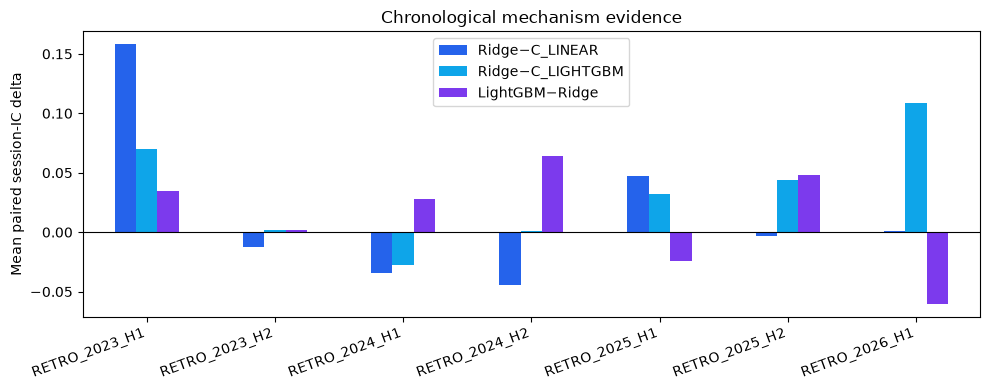

In [4]:
half = pd.DataFrame({
    "Ridge−C_LINEAR": contrasts["RIDGE_VS_C_LINEAR"]["half_year_mean_deltas"],
    "Ridge−C_LIGHTGBM": contrasts["RIDGE_VS_C_LIGHTGBM"]["half_year_mean_deltas"],
    "LightGBM−Ridge": contrasts["NONLINEAR_INCREMENT"]["half_year_mean_deltas"],
})
display(half.style.format("{:+.5f}"))
ax = half.plot(kind="bar", figsize=(10, 4), color=["#2563eb", "#0ea5e9", "#7c3aed"])
ax.axhline(0, color="black", linewidth=.8); ax.set_ylabel("Mean paired session-IC delta")
ax.set_title("Chronological mechanism evidence"); plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

In [5]:
checks = pd.DataFrame({
    "Ridge vs C_LINEAR": contrasts["RIDGE_VS_C_LINEAR"]["broad_increment_checks"],
    "Ridge vs C_LIGHTGBM": contrasts["RIDGE_VS_C_LIGHTGBM"]["broad_increment_checks"],
    "LightGBM vs Ridge": contrasts["NONLINEAR_INCREMENT"]["broad_increment_checks"],
})
display(checks)
display(Markdown(f'''## Mechanical verdict: `{verdict["verdict"]}`

Ridge C+P+X fails against `C_LINEAR`: only
{contrasts["RIDGE_VS_C_LINEAR"]["positive_half_year_count"]}/7 half-years are
positive, the median half-year delta is nonpositive, and leaving out 2023 H1
reverses the pooled delta. LightGBM passes the broad nonlinear-increment gate
with C+P+X held fixed. The accepted LightGBM C+P+X cell retains positive pooled
deltas and at least 4/7 positive half-years against both conventional controls.
'''))

,Ridge vs C_LINEAR,Ridge vs C_LIGHTGBM,LightGBM vs Ridge
all_leave_half_year_out_positive,False,True,True
all_tied_largest_security_out_positive,True,True,True
half_year_positive_share_below_0_50,True,True,True
median_half_year_positive,False,True,True
pooled_mean_gt_0_005,True,True,True
positive_half_years_at_least_5,False,True,True
security_positive_share_below_0_50,True,True,True


## Mechanical verdict: `NONLINEARITY-DEPENDENT — WEAK`

Ridge C+P+X fails against `C_LINEAR`: only
3/7 half-years are
positive, the median half-year delta is nonpositive, and leaving out 2023 H1
reverses the pooled delta. LightGBM passes the broad nonlinear-increment gate
with C+P+X held fixed. The accepted LightGBM C+P+X cell retains positive pooled
deltas and at least 4/7 positive half-years against both conventional controls.


In [6]:
correlation = pd.Series(diagnostics["cpx_mean_session_score_spearman_by_half_year"], name="mean score-rank correlation")
display(correlation.to_frame().style.format("{:.3f}"))
coef = pd.DataFrame({block: record["standardized_coefficients"] for block, record in diagnostics["ridge_coefficients_by_refit"].items()}).T
coef_summary = pd.DataFrame({"positive_refits": (coef > 0).sum(), "negative_refits": (coef < 0).sum(), "median_coefficient": coef.median()}).sort_values("median_coefficient")
display(coef_summary.style.format({"median_coefficient":"{:+.5f}"}))

,mean score-rank correlation
RETRO_2023_H1,0.266
RETRO_2023_H2,0.310
RETRO_2024_H1,0.399
RETRO_2024_H2,0.538
RETRO_2025_H1,0.524
RETRO_2025_H2,0.564
RETRO_2026_H1,0.527


,positive_refits,negative_refits,median_coefficient
proximity_to_max_close_252,3,4,-0.01427
stock_log_return_20,2,5,-0.01353
stock_recovery_from_low_60,2,5,-0.00708
realized_volatility_20,1,6,-0.00326
stock_drawdown_depth_60,2,5,-0.00292
momentum_12_1,0,7,-0.00272
return_5,0,7,-0.00189
xrank_realized_volatility_20,2,5,-0.00153
xrank_relative_volume_20,5,2,+0.00045
relative_volume_20,5,2,+0.00186


## Decision boundary

This result permits discussion of a separately frozen 36m-versus-48m rank-only
diagnostic. It does not authorize execution of that diagnostic. The original D2
`STOP` and the existing prospective LightGBM stream remain unchanged. There is
no portfolio, return, alpha, prospective-confirmation, or deployment claim here.